In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

base_path = r"C:\Users\Admin\Documents\bluestock_mf_capstone"
os.chdir(base_path)

os.makedirs("reports", exist_ok=True)

nav_history = pd.read_csv("data/processed/nav_history_clean.csv")
fund_master = pd.read_csv("data/processed/fund_master_clean.csv")
live_nav = pd.read_csv("data/processed/live_nav_clean.csv")

nav_history['Date'] = pd.to_datetime(nav_history['Date'])

print("✅ Data loaded!")
print("Shape:", nav_history.shape)

✅ Data loaded!
Shape: (150, 4)


In [ ]:
VAR Analysis

=== HISTORICAL VaR ANALYSIS ===


C:\Users\Admin\AppData\Local\Temp\ipykernel_19768\1458823676.py:10: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_returns = nav_pivot.pct_change().dropna()


             Scheme  VaR_95%  CVaR_95%
0     Axis Bluechip  -0.0324   -0.0559
1    ICICI Bluechip  -1.4919   -1.8370
2    Kotak Bluechip  -0.9218   -1.4507
3  Nippon Large Cap  -1.3241   -1.6893
4      SBI Bluechip  -0.1147   -0.1685

✅ VaR Report saved!


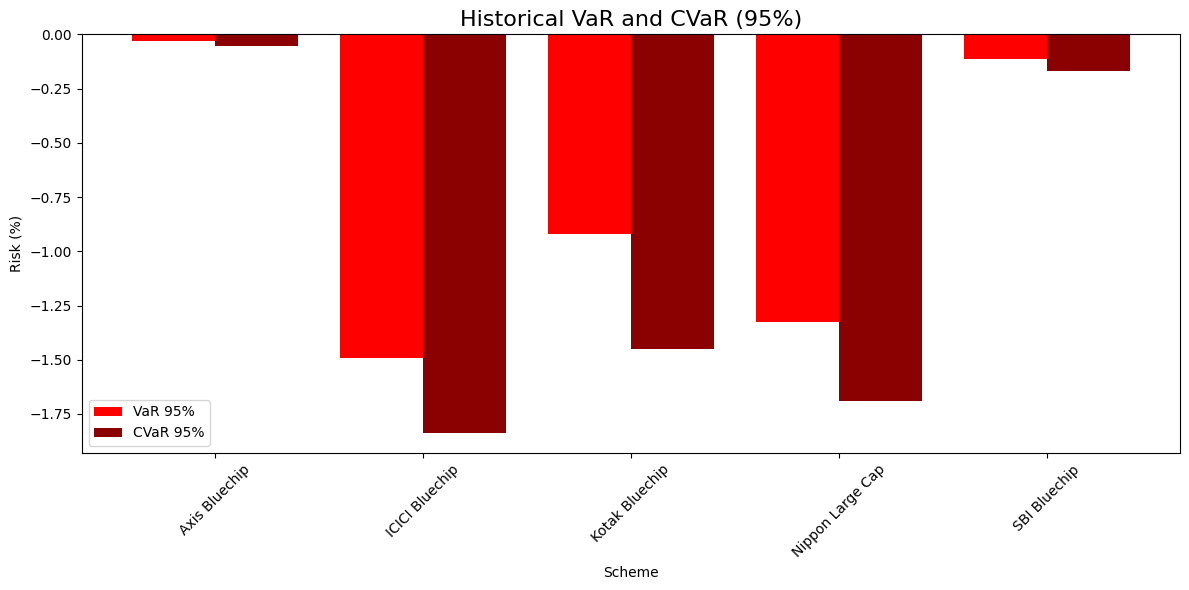

✅ VaR Chart saved!


In [2]:
# Historical VaR (95%) Calculation
print("=== HISTORICAL VaR ANALYSIS ===")

# Calculate daily returns
nav_pivot = nav_history.pivot_table(
    index='Date',
    columns='Scheme',
    values='NAV'
)
daily_returns = nav_pivot.pct_change().dropna()

# Calculate VaR at 95% confidence
var_95 = {}
cvar_95 = {}

for scheme in daily_returns.columns:
    returns = daily_returns[scheme].dropna()
    var = np.percentile(returns, 5)
    cvar = returns[returns <= var].mean()
    var_95[scheme] = round(var * 100, 4)
    cvar_95[scheme] = round(cvar * 100, 4)

# Create VaR report
var_report = pd.DataFrame({
    'Scheme': list(var_95.keys()),
    'VaR_95%': list(var_95.values()),
    'CVaR_95%': list(cvar_95.values())
})

print(var_report)
var_report.to_csv("reports/var_cvar_report.csv", index=False)
print("\n✅ VaR Report saved!")

# Plot VaR
plt.figure(figsize=(12, 6))
x = range(len(var_report))
plt.bar([i - 0.2 for i in x],
        var_report['VaR_95%'],
        width=0.4,
        label='VaR 95%',
        color='red')
plt.bar([i + 0.2 for i in x],
        var_report['CVaR_95%'],
        width=0.4,
        label='CVaR 95%',
        color='darkred')
plt.xticks(list(x), var_report['Scheme'], rotation=45)
plt.title('Historical VaR and CVaR (95%)', fontsize=16)
plt.xlabel('Scheme')
plt.ylabel('Risk (%)')
plt.legend()
plt.tight_layout()
plt.savefig('reports/var_cvar_chart.png', dpi=150)
plt.show()
print("✅ VaR Chart saved!")

In [ ]:
Sharpe Ratio

=== ROLLING SHARPE RATIO ===


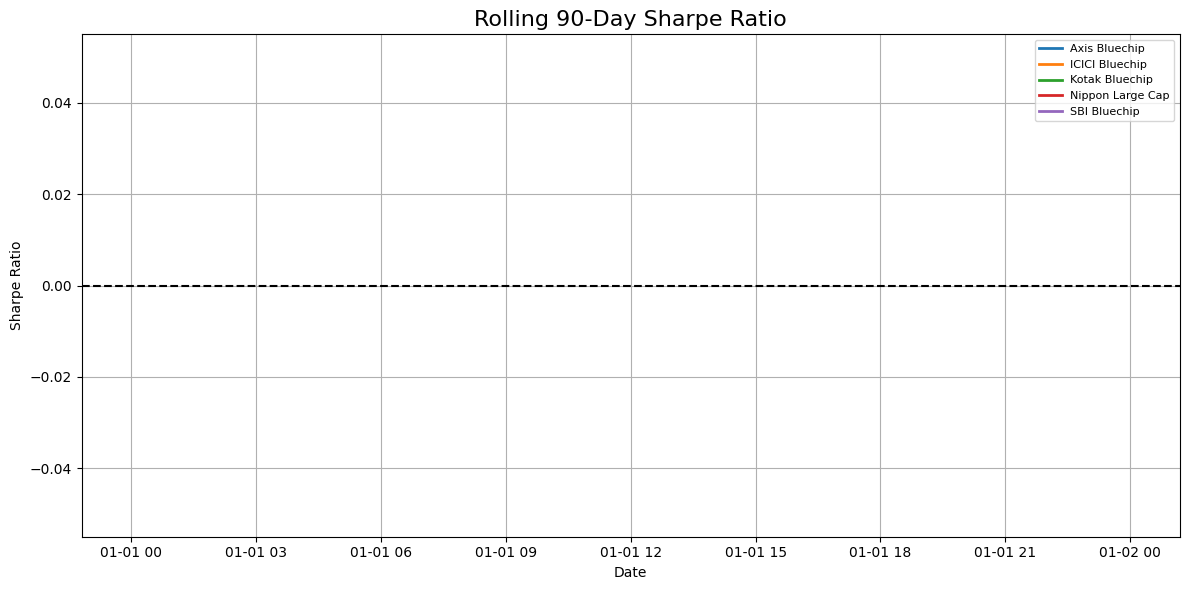

✅ Rolling Sharpe Chart saved!


In [3]:
# Rolling 90-day Sharpe Ratio
print("=== ROLLING SHARPE RATIO ===")

plt.figure(figsize=(12, 6))

for scheme in daily_returns.columns:
    returns = daily_returns[scheme].dropna()
    
    # Calculate rolling 90-day Sharpe
    rolling_mean = returns.rolling(90).mean()
    rolling_std = returns.rolling(90).std()
    rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
    
    plt.plot(rolling_sharpe.index,
             rolling_sharpe.values,
             label=scheme,
             linewidth=2)

plt.title('Rolling 90-Day Sharpe Ratio', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend(fontsize=8)
plt.grid(True)
plt.axhline(y=0, color='black', linestyle='--')
plt.tight_layout()
plt.savefig('reports/rolling_sharpe_chart.png', dpi=150)
plt.show()
print("✅ Rolling Sharpe Chart saved!")

In [ ]:
Fund Recommender

In [4]:
# Simple Fund Recommender
print("=== FUND RECOMMENDER ===")

# Calculate metrics for each scheme
metrics = []
for scheme in daily_returns.columns:
    returns = daily_returns[scheme].dropna()
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252)
    var = np.percentile(returns, 5) * 100
    avg_return = returns.mean() * 252 * 100
    
    metrics.append({
        'Scheme': scheme,
        'Annual_Return%': round(avg_return, 2),
        'Sharpe_Ratio': round(sharpe, 4),
        'VaR_95%': round(var, 4),
        'Risk_Grade': 'Low' if abs(var) < 1 
                     else 'Moderate' if abs(var) < 2 
                     else 'High'
    })

metrics_df = pd.DataFrame(metrics)
print(metrics_df)

# Recommender function
def recommend_funds(risk_appetite):
    filtered = metrics_df[
        metrics_df['Risk_Grade'] == risk_appetite
    ].nlargest(3, 'Sharpe_Ratio')
    return filtered[['Scheme', 'Sharpe_Ratio', 
                     'Annual_Return%']]

print("\n=== LOW RISK FUNDS ===")
print(recommend_funds('Low'))
print("\n=== MODERATE RISK FUNDS ===")
print(recommend_funds('Moderate'))
print("\n=== HIGH RISK FUNDS ===")
print(recommend_funds('High'))

metrics_df.to_csv("reports/recommender.csv", index=False)
print("\n✅ Recommender saved!")

=== FUND RECOMMENDER ===
             Scheme  Annual_Return%  Sharpe_Ratio  VaR_95% Risk_Grade
0     Axis Bluechip            2.05        3.5504  -0.0324        Low
1    ICICI Bluechip          -24.96       -1.8659  -1.4919   Moderate
2    Kotak Bluechip           43.40        3.2270  -0.9218        Low
3  Nippon Large Cap          -32.17       -2.4808  -1.3241   Moderate
4      SBI Bluechip           -1.11       -0.8432  -0.1147        Low

=== LOW RISK FUNDS ===
           Scheme  Sharpe_Ratio  Annual_Return%
0   Axis Bluechip        3.5504            2.05
2  Kotak Bluechip        3.2270           43.40
4    SBI Bluechip       -0.8432           -1.11

=== MODERATE RISK FUNDS ===
             Scheme  Sharpe_Ratio  Annual_Return%
1    ICICI Bluechip       -1.8659          -24.96
3  Nippon Large Cap       -2.4808          -32.17

=== HIGH RISK FUNDS ===
Empty DataFrame
Columns: [Scheme, Sharpe_Ratio, Annual_Return%]
Index: []

✅ Recommender saved!


In [ ]:
Advanced Insights

In [5]:
# 5 Advanced Insights
print("=== 5 ADVANCED INSIGHTS ===")

insights = """
# Advanced Analytics Insights
# Bluestock Mutual Fund Analytics

## Insight 1: Highest VaR Risk Fund
highest_var = var_report.loc[
    var_report['VaR_95%'].idxmin(), 'Scheme']
print(f"Insight 1: {highest_var} has highest risk (VaR)")

## Insight 2: Best Sharpe Ratio Fund
best_sharpe = metrics_df.loc[
    metrics_df['Sharpe_Ratio'].idxmax(), 'Scheme']
print(f"Insight 2: {best_sharpe} has best risk-adjusted returns")

## Insight 3: Most Consistent Fund
most_consistent = daily_returns.std().idxmin()
print(f"Insight 3: {most_consistent} is most consistent")

## Insight 4: Highest Returns Fund
best_returns = metrics_df.loc[
    metrics_df['Annual_Return%'].idxmax(), 'Scheme']
print(f"Insight 4: {best_returns} has highest annual returns")

## Insight 5: NAV Correlation
avg_corr = daily_returns.corr().mean().mean()
print(f"Insight 5: Average correlation between funds: {avg_corr:.4f}")
"""

# Execute insights
highest_var = var_report.loc[
    var_report['VaR_95%'].idxmin(), 'Scheme']
print(f"1. {highest_var} has highest risk (VaR)")

best_sharpe = metrics_df.loc[
    metrics_df['Sharpe_Ratio'].idxmax(), 'Scheme']
print(f"2. {best_sharpe} has best Sharpe Ratio")

most_consistent = daily_returns.std().idxmin()
print(f"3. {most_consistent} is most consistent fund")

best_returns = metrics_df.loc[
    metrics_df['Annual_Return%'].idxmax(), 'Scheme']
print(f"4. {best_returns} has highest annual returns")

avg_corr = daily_returns.corr().mean().mean()
print(f"5. Average correlation: {avg_corr:.4f}")

# Save insights
with open('reports/advanced_insights.md', 'w') as f:
    f.write(f"""# Advanced Analytics Insights

1. **Highest Risk Fund:** {highest_var}
2. **Best Sharpe Ratio:** {best_sharpe}
3. **Most Consistent:** {most_consistent}
4. **Highest Returns:** {best_returns}
5. **Avg Correlation:** {avg_corr:.4f}
""")

print("\n✅ Advanced Insights saved!")

=== 5 ADVANCED INSIGHTS ===
1. ICICI Bluechip has highest risk (VaR)
2. Axis Bluechip has best Sharpe Ratio
3. Axis Bluechip is most consistent fund
4. Kotak Bluechip has highest annual returns
5. Average correlation: 0.5126

✅ Advanced Insights saved!
